In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
def load_data(file_path):
    try:
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
df = load_data("../../Database/PDF/Customer-Churn-dataset.csv")

In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [5]:
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

## Data visualization

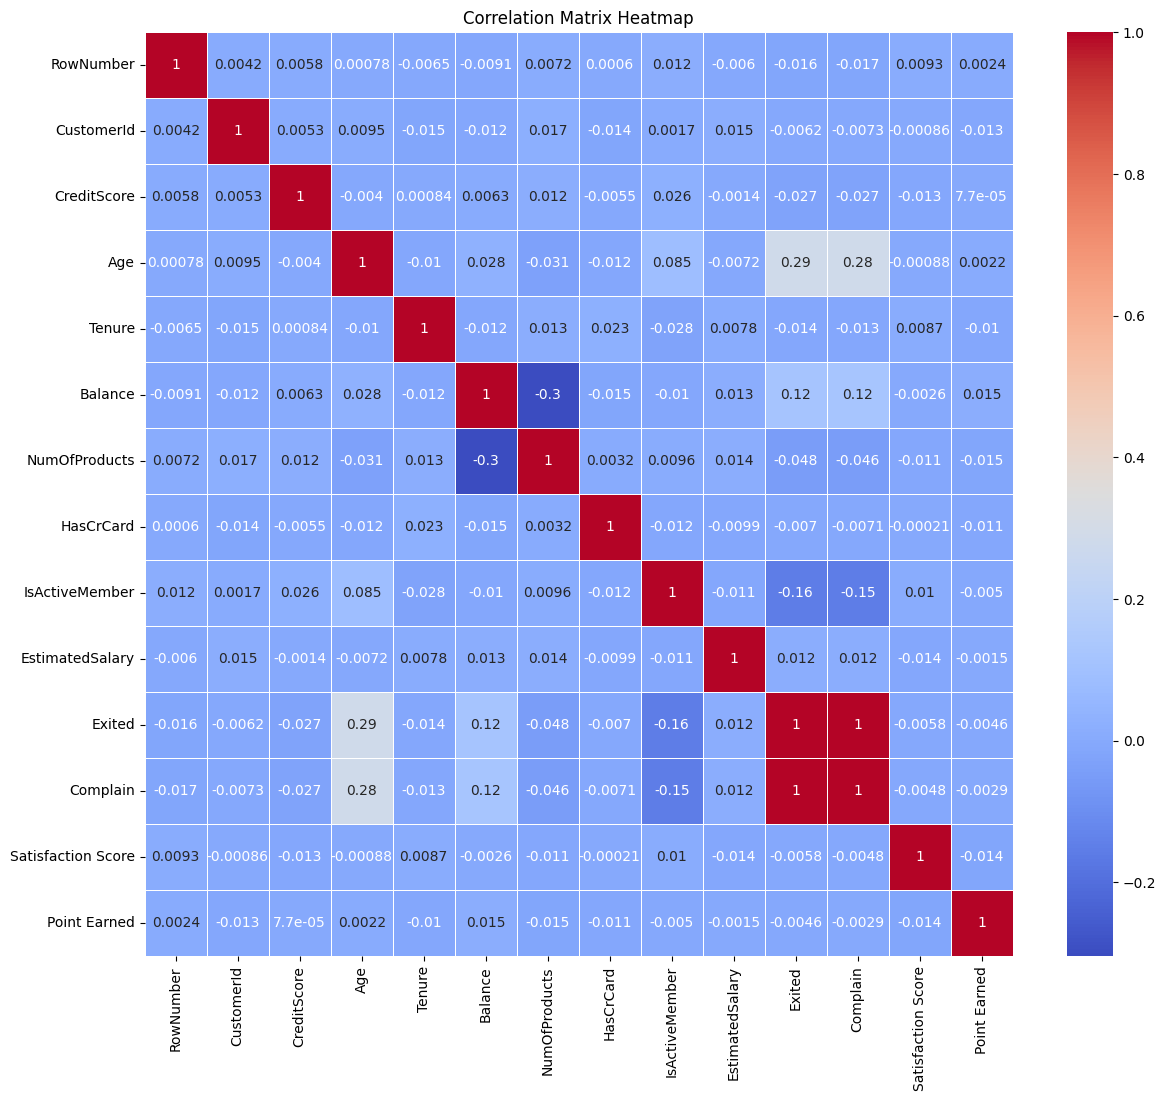

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix heatmap
corr = df.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

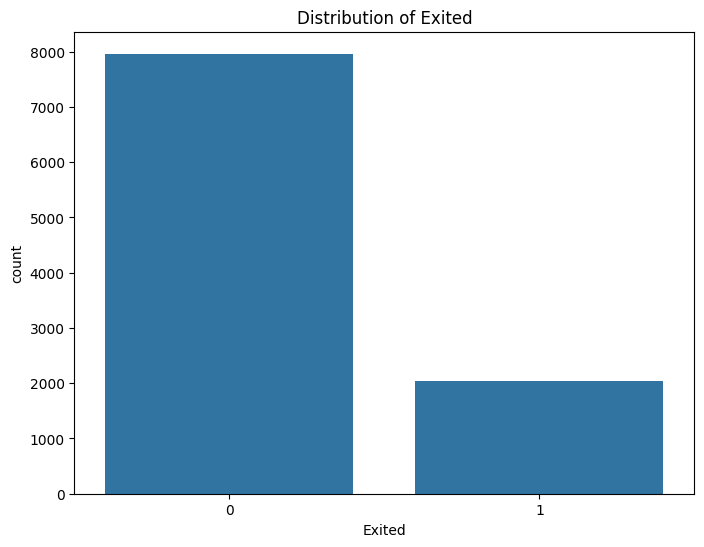

In [7]:
# Most data affected to churn (exited)
plt.figure(figsize=(8, 6))
sns.countplot(x='Exited', data=df)
plt.title('Distribution of Exited')
plt.show()

## Data Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode categorical variables
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,1115,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,2,15647311,1177,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,3,15619304,2040,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,4,15701354,289,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,5,15737888,1822,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,1999,771,0,1,39,5,0.00,2,1,0,96270.64,0,0,1,0,300
9996,9997,15569892,1336,516,0,1,35,10,57369.61,1,1,1,101699.77,0,0,5,2,771
9997,9998,15584532,1570,709,0,0,36,7,0.00,1,0,1,42085.58,1,1,3,3,564
9998,9999,15682355,2345,772,1,1,42,3,75075.31,2,1,0,92888.52,1,1,2,1,339


## Split data into X and y

In [9]:
from sklearn.model_selection import train_test_split

# Define FEATURES as X and y as target variable
FEATURES = [col for col in df.columns if col != 'Exited']
TARGET = 'Exited'

# Define X as features and y as target variable
X = df[FEATURES]
y = df[TARGET]

# Split data into X and y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Data Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

print(f"Data shape after scaling: {X_train_scaled.shape}, {X_test_scaled.shape}")

Data shape after scaling: (8000, 17), (2000, 17)


## Machine learning model

In [12]:
"""Set classified machine learning models because the data is classified data (data target is binary)"""
import warnings
warnings.filterwarnings("ignore")
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Define model
model = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

# Hyperparameter tuning for all models
param_dist = {
    "Decision Tree": {
        "max_depth": [10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1],
        "penalty": ['l1', 'l2'],
        "solver": ['liblinear']
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [10, 20, 30],
        "learning_rate": [0.01, 0.1, 0.2],
        "subsample": [0.8, 1]
    }
}

# Use randomized search for hyperparameter tuning
def tune_model(model, param_dist, X_train, y_train):
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=10,
        cv=5,
        verbose=0,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    return random_search.best_estimator_
    
# Train and evaluate models
for name, clf in model.items():
    print(f"Training model {name}...")
    best_clf = tune_model(clf, param_dist[name], X_train_scaled, y_train)
    y_pred = best_clf.predict(X_test_scaled)
    print(f"Classification report for {name}:\n{classification_report(y_test, y_pred)}")
    precision_score_value = precision_score(y_test, y_pred)
    recall_score_value = recall_score(y_test, y_pred)
    f1_score_value = f1_score(y_test, y_pred)
    accuracy_score_value = accuracy_score(y_test, y_pred)
    print(f"Precision: {precision_score_value:.4f}")
    print(f"Recall: {recall_score_value:.4f}")
    print(f"F1 Score: {f1_score_value:.4f}")
    print(f"Accuracy: {accuracy_score_value:.4f}")

Training model Decision Tree...
Classification report for Decision Tree:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      0.99      0.99       408

    accuracy                           1.00      2000
   macro avg       1.00      0.99      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Precision: 1.0000
Recall: 0.9853
F1 Score: 0.9926
Accuracy: 0.9970
Training model Random Forest...
Classification report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Precision: 0.9975
Recall: 0.9951
F1 Score: 0.9963
Accuracy: 0.9985
Training model Logistic Regression...
Classification report for Lo

## Visualization for confusion matrix

Confusion matrix for Decision Tree:


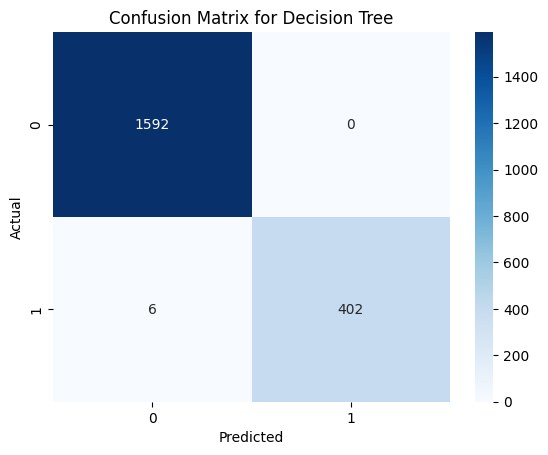

Confusion matrix for Random Forest:


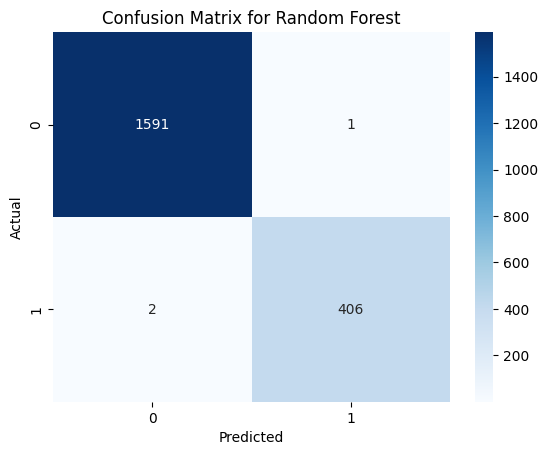

Confusion matrix for Logistic Regression:


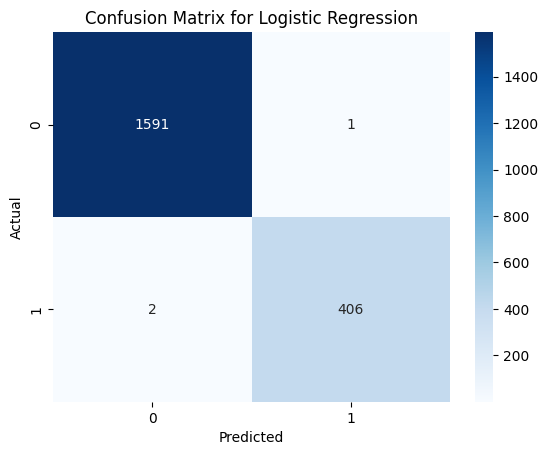

Confusion matrix for XGBoost:


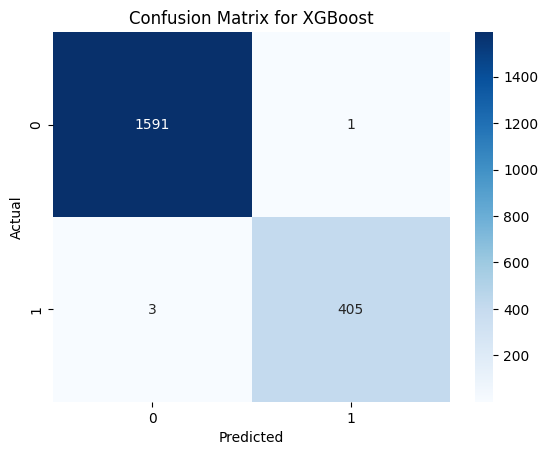

In [13]:
# Create plot for confusion matrix of each model
for name, clf in model.items():
    print(f"Confusion matrix for {name}:")
    best_clf = tune_model(clf, param_dist[name], X_train_scaled, y_train)
    y_pred = best_clf.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()